In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [5]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes

100%|██████████| 170M/170M [00:02<00:00, 76.5MB/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2562718].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.3247709].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2186929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6979957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..0.96515113].
C

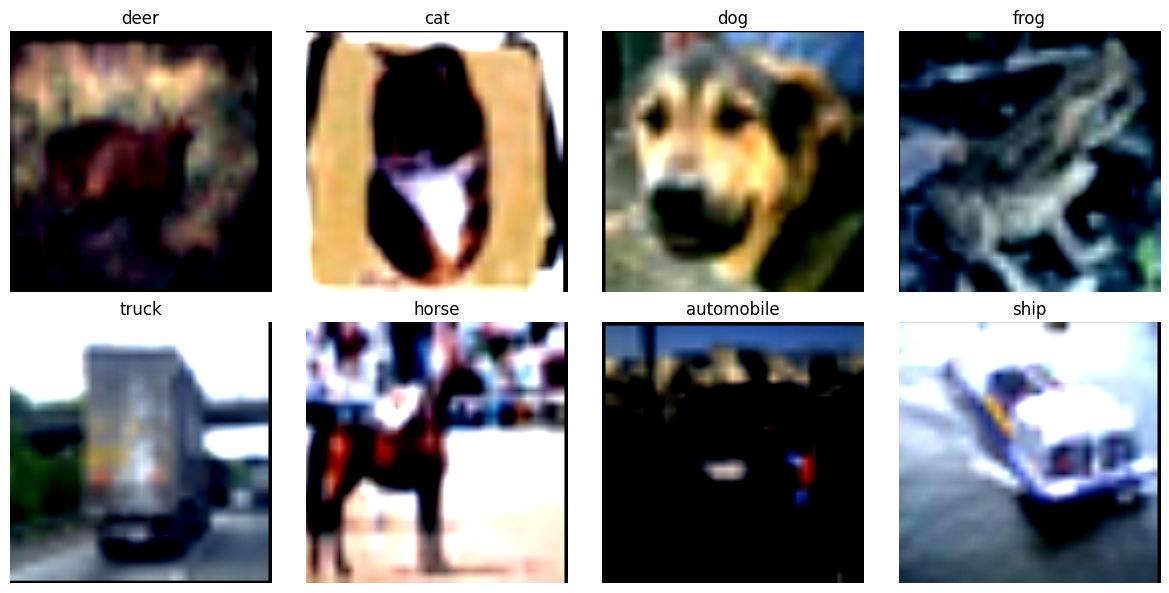

In [6]:
def show_images(images, labels, classes):
    plt.figure(figsize=(12,6))
    for i in range(8):
        plt.subplot(2,4,i+1)
        img = images[i] / 2 + 0.5  # unnormalize
        npimg = img.numpy()
        plt.imshow(np.transpose(npimg, (1,2,0)))
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Get a batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
show_images(images, labels, classes)

In [7]:
model = models.resnet18(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [9]:
def train(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

In [10]:
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100. * correct / total
    return running_loss / len(loader), acc, all_preds, all_labels

In [11]:
EPOCHS = 5

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%\n")

Epoch 1/5
Train Loss: 0.8357, Train Acc: 73.44%
Val   Loss: 0.6184, Val   Acc: 79.39%

Epoch 2/5
Train Loss: 0.6130, Train Acc: 79.18%
Val   Loss: 0.5975, Val   Acc: 79.69%

Epoch 3/5
Train Loss: 0.5887, Train Acc: 79.65%
Val   Loss: 0.5779, Val   Acc: 80.15%

Epoch 4/5
Train Loss: 0.5724, Train Acc: 80.25%
Val   Loss: 0.5883, Val   Acc: 79.71%

Epoch 5/5
Train Loss: 0.5653, Train Acc: 80.63%
Val   Loss: 0.5718, Val   Acc: 80.52%



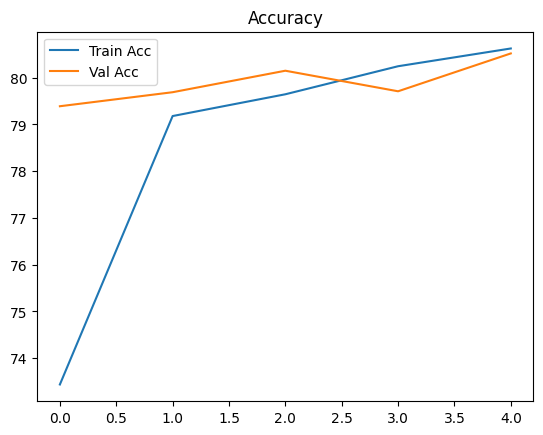

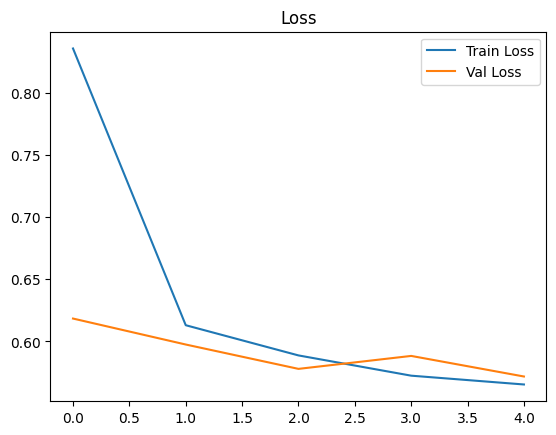

In [12]:
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

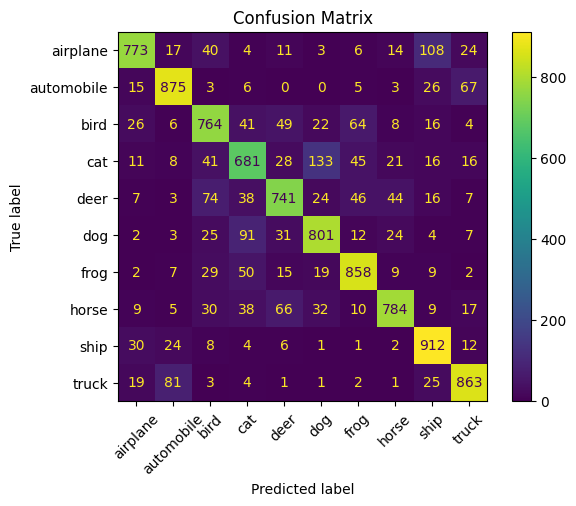

In [13]:
_, _, preds, labels = evaluate(model, test_loader)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [14]:
def add_noise(images, noise_level=0.1):
    if noise_level == 0.0:
        return images
    noise = torch.randn_like(images) * noise_level
    noisy = images + noise
    return torch.clamp(noisy, 0., 1.)

In [15]:
def denormalize(img, mean, std):
    mean = torch.tensor(mean).view(1,3,1,1).to(img.device)
    std = torch.tensor(std).view(1,3,1,1).to(img.device)
    return img * std + mean

def normalize(img, mean, std):
    mean = torch.tensor(mean).view(1,3,1,1).to(img.device)
    std = torch.tensor(std).view(1,3,1,1).to(img.device)
    return (img - mean) / std

In [16]:
def evaluate_with_noise(model, loader, noise_level):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # step 1: denormalize
            images = denormalize(images, mean, std)

            # step 2: add noise
            noisy_images = add_noise(images, noise_level)

            # step 3: normalize again
            noisy_images = normalize(noisy_images, mean, std)

            # step 4: predict
            outputs = model(noisy_images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

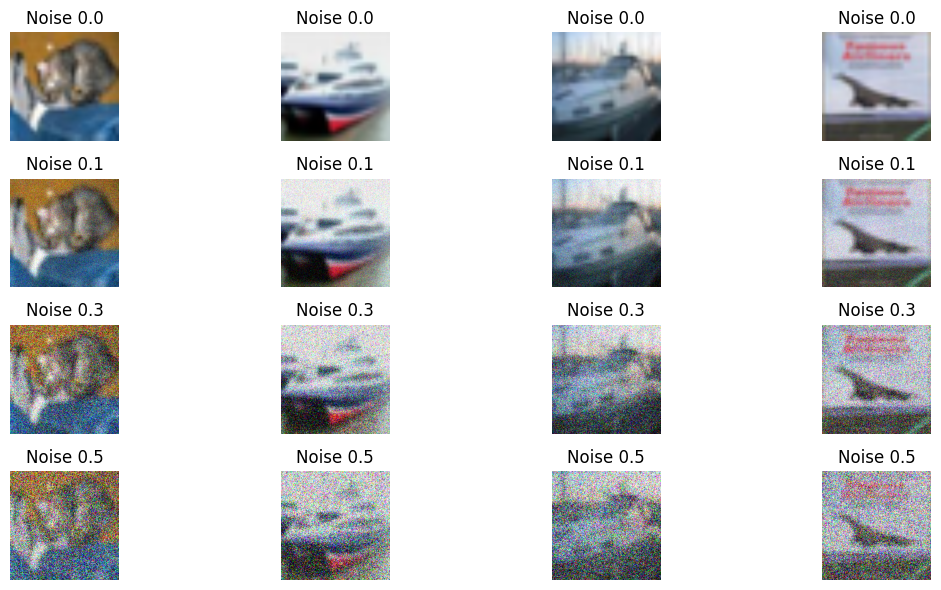

In [17]:
def show_noise_levels(images):
    noise_levels = [0.0, 0.1, 0.3, 0.5]

    plt.figure(figsize=(12,6))

    for i, nl in enumerate(noise_levels):
        img = denormalize(images.clone(), mean, std)
        noisy = add_noise(img, nl)

        for j in range(4):
            plt.subplot(len(noise_levels), 4, i*4 + j + 1)
            im = noisy[j].cpu().numpy().transpose(1,2,0)
            plt.imshow(im)
            plt.title(f"Noise {nl}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# call this
images, _ = next(iter(test_loader))
show_noise_levels(images.to(device))

In [18]:
noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
results = []

for nl in noise_levels:
    acc = evaluate_with_noise(model, test_loader, nl)
    results.append(acc)
    print(f"Noise Level {nl}: Accuracy = {acc:.2f}%")

Noise Level 0.0: Accuracy = 80.52%
Noise Level 0.1: Accuracy = 15.95%
Noise Level 0.3: Accuracy = 10.00%
Noise Level 0.5: Accuracy = 9.61%
Noise Level 0.7: Accuracy = 8.71%
Noise Level 1.0: Accuracy = 9.85%


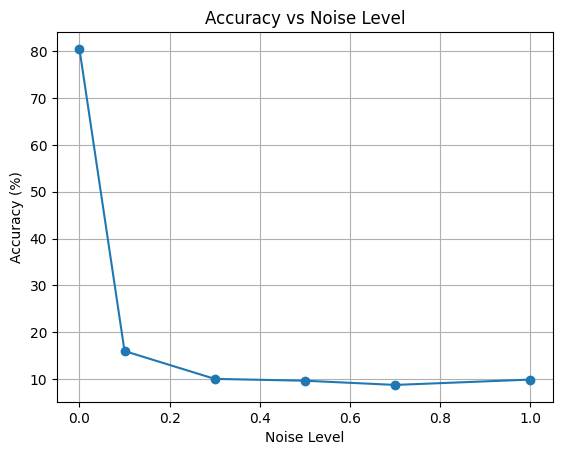

In [19]:
plt.figure()
plt.plot(noise_levels, results, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Noise Level")
plt.grid()
plt.show()

In [20]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        d1 = self.dec1(e3) + e2
        d2 = self.dec2(d1) + e1
        out = self.dec3(d2)

        return out   # 🔥 NO addition with input

In [21]:
def train_autoencoder(model, loader, epochs=15):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    # 🔥 better loss (sharp + stable)
    def loss_fn(pred, target):
        return 0.8 * nn.L1Loss()(pred, target) + 0.2 * nn.MSELoss()(pred, target)

    # 🔥 early stopping setup
    best_loss = float('inf')
    patience = 3
    counter = 0

    for epoch in range(epochs):
        total_loss = 0

        # 🔥 curriculum noise (easy → medium)
        if epoch < 5:
            noise_choices = [0.1, 0.2]
            probs = [0.7, 0.3]
        elif epoch < 10:
            noise_choices = [0.1, 0.2, 0.3]
            probs = [0.4, 0.4, 0.2]
        else:
            noise_choices = [0.1, 0.2, 0.3, 0.4]
            probs = [0.3, 0.3, 0.25, 0.15]

        for images, _ in loader:
            images = images.to(device)

            # 🔹 Step 1: denormalize
            clean = denormalize(images, mean, std)

            # 🔹 Step 2: sample noise
            nl = np.random.choice(noise_choices, p=probs)

            # 🔹 Step 3: add noise
            noisy = add_noise(clean, nl)
            noisy = torch.clamp(noisy, 0, 1)

            optimizer.zero_grad()

            # 🔹 Step 4: forward
            output = model(noisy)

            # 🔹 Step 5: ensure valid range
            output = torch.clamp(output, 0, 1)

            # 🔹 Step 6: loss
            loss = loss_fn(output, clean)

            # 🔹 Step 7: backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        # 🔥 early stopping logic
        if avg_loss < best_loss:
            best_loss = avg_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

In [22]:
autoencoder = DenoisingAutoencoder().to(device)
train_autoencoder(autoencoder, train_loader, epochs=15)

Epoch 1, Loss: 0.0285
Epoch 2, Loss: 0.0193
Epoch 3, Loss: 0.0178
Epoch 4, Loss: 0.0167
Epoch 5, Loss: 0.0163
Epoch 6, Loss: 0.0168
Epoch 7, Loss: 0.0166
Epoch 8, Loss: 0.0161
Epoch 9, Loss: 0.0151
Epoch 10, Loss: 0.0147
Epoch 11, Loss: 0.0164
Epoch 12, Loss: 0.0160
Epoch 13, Loss: 0.0161
Early stopping triggered


In [23]:
images, _ = next(iter(test_loader))
images = images.to(device)

# denormalize
clean = denormalize(images, mean, std)

# add noise
noisy = add_noise(clean, 0.3)

# get prediction
with torch.no_grad():
    pred_noise = autoencoder(noisy)

print(pred_noise.mean().item(), pred_noise.std().item())

0.43243408203125 0.2496996372938156


In [24]:
def show_denoising(autoencoder, images):
    autoencoder.eval()

    # Step 1: denormalize
    clean = denormalize(images.clone(), mean, std)

    # Step 2: add noise
    noisy = add_noise(clean, 0.3)

    # Step 3: denoise (DIRECT OUTPUT)
    with torch.no_grad():
        denoised = autoencoder(noisy)

    # Step 4: clamp for safety
    denoised = torch.clamp(denoised, 0, 1)

    # Step 5: plot
    plt.figure(figsize=(12,6))

    for i in range(4):
        # 🔴 Noisy
        plt.subplot(3,4,i+1)
        plt.imshow(noisy[i].cpu().numpy().transpose(1,2,0))
        plt.title("Noisy")
        plt.axis('off')

        # 🟢 Denoised
        plt.subplot(3,4,i+5)
        plt.imshow(denoised[i].cpu().numpy().transpose(1,2,0))
        plt.title("Denoised")
        plt.axis('off')

        # 🔵 Clean
        plt.subplot(3,4,i+9)
        plt.imshow(clean[i].cpu().numpy().transpose(1,2,0))
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

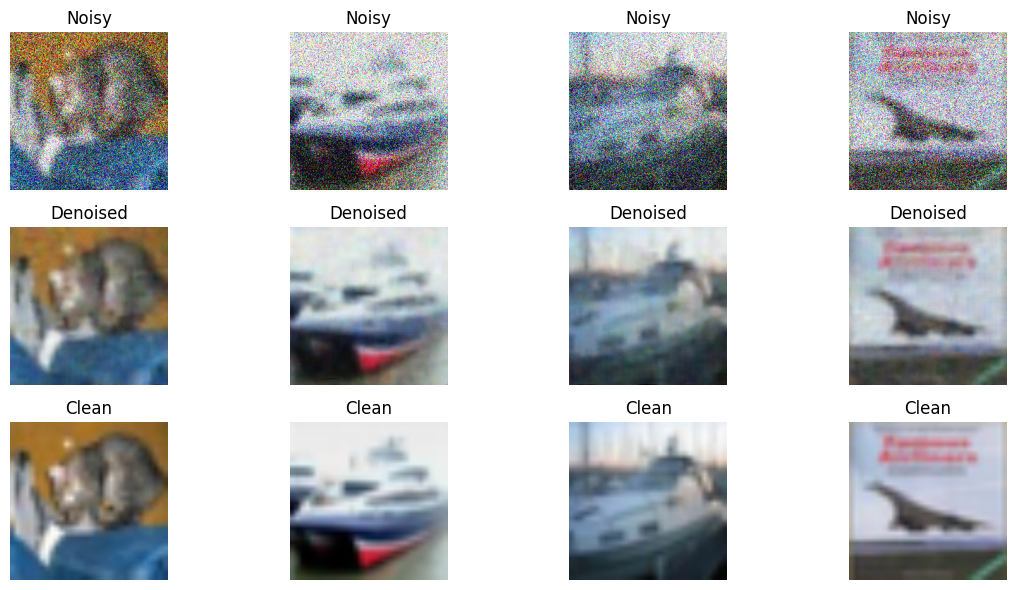

In [25]:
show_denoising(autoencoder, images.to(device))

In [26]:
def evaluate_with_denoising(model, autoencoder, loader, noise_level):
    model.eval()
    autoencoder.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # step 1: denormalize
            clean = denormalize(images, mean, std)

            # step 2: handle noise
            if noise_level == 0.0:
                # IMPORTANT: skip autoencoder
                processed = images   # already normalized
            else:
                noisy = add_noise(clean, noise_level)

                # denoise
                denoised = autoencoder(noisy)

                # clamp (VERY IMPORTANT)
                denoised = torch.clamp(denoised, 0, 1)

                # normalize again
                processed = normalize(denoised, mean, std)

            # step 3: classify
            outputs = model(processed)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

In [27]:
noise_levels = [0.0, 0.1, 0.3, 0.5]

print("=== WITH AUTOENCODER ===")
for nl in noise_levels:
    acc = evaluate_with_denoising(model, autoencoder, test_loader, nl)
    print(f"Noise {nl}: Accuracy = {acc:.2f}%")

=== WITH AUTOENCODER ===
Noise 0.0: Accuracy = 80.52%
Noise 0.1: Accuracy = 58.37%
Noise 0.3: Accuracy = 39.82%
Noise 0.5: Accuracy = 19.67%
